# Fluid Mechanics — Chapter 4: Visualizations

Companion notebook for Ch. 4 (*Irrotational Flow*) problem-solution slides.

| Problem | Visualization | Figure |
|---------|---------------|--------|
| 4.2 | Line source/sink — streamlines & equipotentials | `fig_4_2_source.png` |
| 4.3 | Cylinder in stagnation-like flow (Blasius moment) | `fig_4_3_cylinder_stagnation.png` |
| 4.4 | Cylinder with circulation — stagnation points | `fig_4_4_cylinder_circulation.png` |
| 4.6 | Kutta condition — surface speed vs α | `fig_4_6_kutta.png` |
| 4.7 | Flat-plate aerofoil — pressure distribution | `fig_4_7_flatplate.png` |
| 4.8 | Joukowski transform — circle to circular arc | `fig_4_8_joukowski.png` |
| 4.9 | Source between walls — images vs mapping | `fig_4_9_source_walls.png` |
| 4.10 | Aerofoil pair — far-field & drag | `fig_4_10_pair_drag.png` |

All figures saved to `../figures/` for use in the Quarto slides.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch
from pathlib import Path

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
})
print(f'Figures will be saved to: {FIG_DIR.resolve()}')

Figures will be saved to: /figures


---
## Problem 4.2 — Line Source / Sink

Complex potential $w = \dfrac{Q}{2\pi}\log z$,
giving $\phi = \dfrac{Q}{2\pi}\ln r$ (radial equipotentials) and
$\psi = \dfrac{Q}{2\pi}\theta$ (ray streamlines).

Left: source ($Q>0$). Right: sink ($Q<0$) with image source for wall $x=0$.


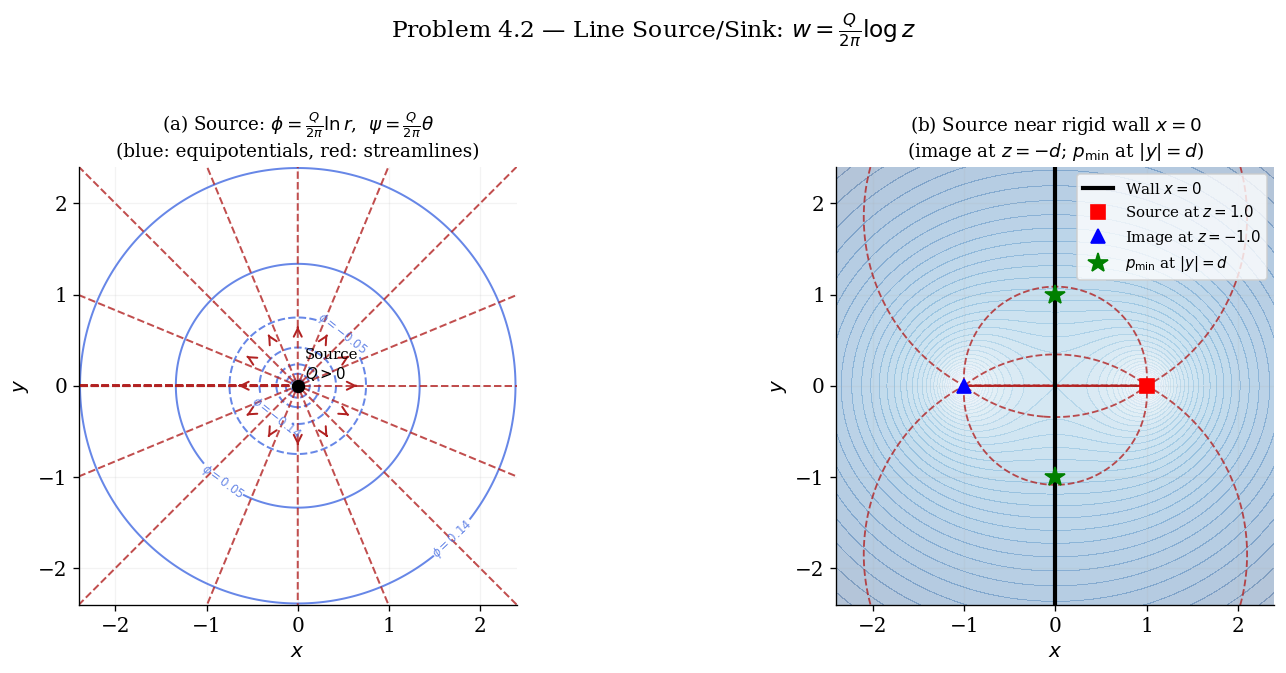

Saved: fig_4_2_source.png


In [2]:
\
Q = 1.0   # source strength

x = np.linspace(-2.5, 2.5, 600)
y = np.linspace(-2.5, 2.5, 600)
X, Y = np.meshgrid(x, y)
R    = np.sqrt(X**2 + Y**2)
R    = np.where(R < 0.05, np.nan, R)   # mask origin
PHI  = Q/(2*np.pi) * np.log(R)
PSI  = Q/(2*np.pi) * np.arctan2(Y, X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: pure source ─────────────────────────────────────────────────────────
ax = axes[0]
levels_phi = np.linspace(-0.6, 0.6, 14)
levels_psi = np.linspace(-np.pi, np.pi, 17) * Q/(2*np.pi)

cp = ax.contour(X, Y, PHI, levels=levels_phi, colors='royalblue',
                linewidths=1.2, alpha=0.8)
cs = ax.contour(X, Y, PSI, levels=levels_psi, colors='firebrick',
                linewidths=1.2, alpha=0.8, linestyles='--')
ax.clabel(cp, fmt=r'$\phi=%.2f$', fontsize=7, inline=True)

# Arrows along a few streamlines
for theta in np.linspace(0, 2*np.pi, 13)[:-1]:
    r0, r1 = 0.6, 0.65
    ax.annotate('', xy=(r1*np.cos(theta), r1*np.sin(theta)),
                xytext=(r0*np.cos(theta), r0*np.sin(theta)),
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=1.2))

ax.plot(0, 0, 'ko', ms=7, zorder=6)
ax.text(0.08, 0.08, 'Source\n$Q>0$', fontsize=9, color='k')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title(r'(a) Source: $\phi=\frac{Q}{2\pi}\ln r$,  $\psi=\frac{Q}{2\pi}\theta$'
             '\n(blue: equipotentials, red: streamlines)', fontsize=11)
ax.set_aspect('equal'); ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4)
ax.grid(True, alpha=0.15)

# ── Right: sink at z=d with image source at z=-d, wall at x=0 ────────────────
ax = axes[1]
d = 1.0

X2, Y2 = X.copy(), Y.copy()
R1 = np.sqrt((X2-d)**2 + Y2**2); R1 = np.where(R1<0.05, np.nan, R1)
R2 = np.sqrt((X2+d)**2 + Y2**2); R2 = np.where(R2<0.05, np.nan, R2)
T1 = np.arctan2(Y2, X2 - d)
T2 = np.arctan2(Y2, X2 + d)

# Sink at +d, image source at -d  (w = Q/(2pi)[log(z-d)+log(z+d)])
PSI2 = Q/(2*np.pi) * (T1 - T2)   # sink uses -Q → flip sign
PHI2 = Q/(2*np.pi) * (np.log(R1) + np.log(R2))

levels_psi2 = np.linspace(-1.5, 1.5, 20)
cs2 = ax.contour(X2, Y2, PSI2, levels=levels_psi2, colors='firebrick',
                 linewidths=1.1, alpha=0.8, linestyles='--')
ax.contourf(X2, Y2, PHI2, levels=40, cmap='Blues', alpha=0.30)
ax.axvline(0, color='k', lw=2.5, label='Wall $x=0$')
ax.plot( d, 0, 'rs', ms=8, zorder=6, label=f'Source at $z={d}$')
ax.plot(-d, 0, 'b^', ms=8, zorder=6, label=f'Image at $z=-{d}$')

# Minimum pressure marker on wall
ax.plot(0,  d, 'g*', ms=12, zorder=7, label=r'$p_{\min}$ at $|y|=d$')
ax.plot(0, -d, 'g*', ms=12, zorder=7)

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(b) Source near rigid wall $x=0$\n'
             r'(image at $z=-d$; $p_{\min}$ at $|y|=d$)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal'); ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4)
ax.grid(True, alpha=0.15)

plt.suptitle(r"Problem 4.2 — Line Source/Sink: $w=\frac{Q}{2\pi}\log z$",
             fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_4_2_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_2_source.png')

---
## Problem 4.3 — Cylinder in Stagnation-Like Flow

$w(z) = \dfrac{A}{2i}\!\left(z^2-2cz-\dfrac{a^4}{z^2}+\dfrac{2ca^2}{z}\right)$

Left: streamlines of combined flow (cylinder + stagnation stream).
Right: pressure map with Blasius moment $\mathcal{N}=-\pi\rho A^2 a^4$ indicated.


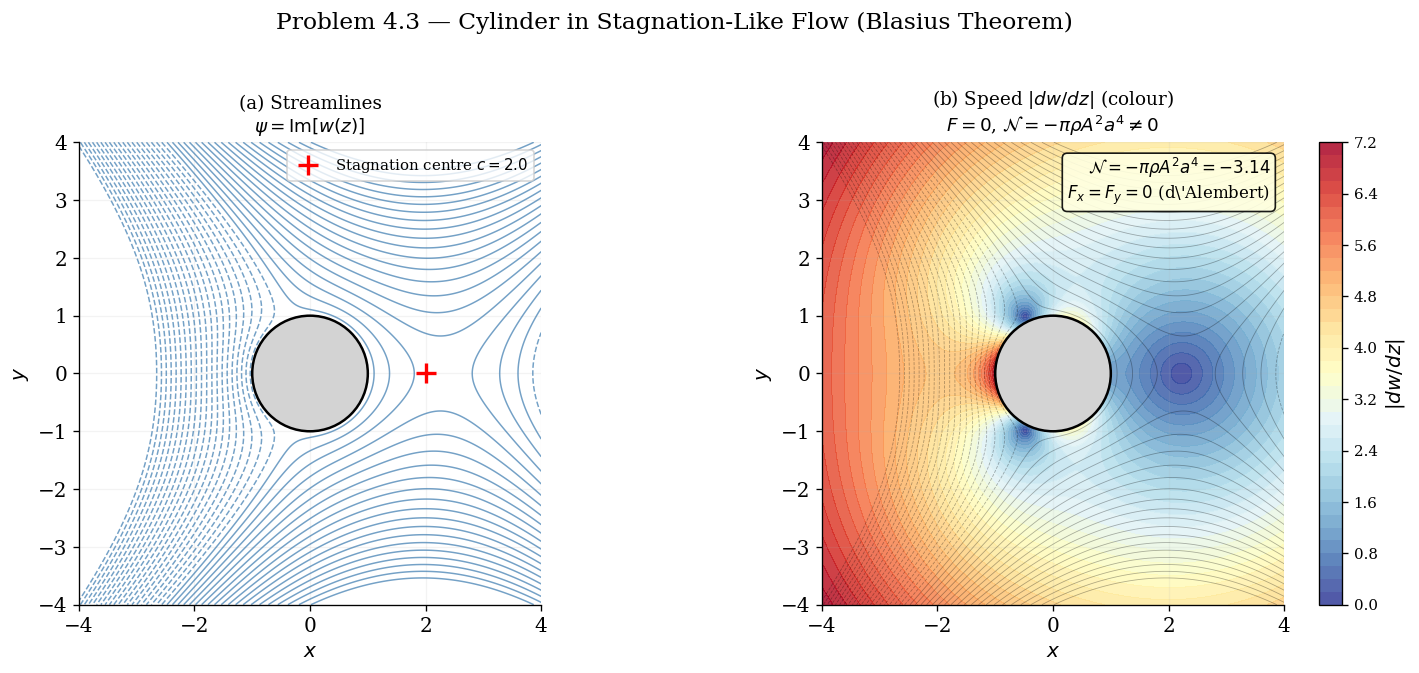

Saved: fig_4_3_cylinder_stagnation.png


In [3]:
\
A, c, a = 1.0, 2.0, 1.0
rho = 1.0

x = np.linspace(-4, 4, 700)
y = np.linspace(-4, 4, 700)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Mask interior of cylinder
mask = np.sqrt(X**2 + Y**2) < a

def w_func(z):
    return (A/(2j)) * (z**2 - 2*c*z - a**4/z**2 + 2*c*a**2/z)

def dw_func(z):
    return (A/(2j)) * (2*z - 2*c + 4*a**4/z**3 - 2*c*a**2/z**2)

W  = w_func(Z)
PSI = np.where(mask, np.nan, np.imag(W))

dW = dw_func(Z)
speed = np.where(mask, np.nan, np.abs(dW))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: streamlines ─────────────────────────────────────────────────────────
ax = axes[0]
levels = np.linspace(-8, 8, 40)
ax.contour(X, Y, PSI, levels=levels, colors='steelblue', linewidths=0.9, alpha=0.75)
cyl = Circle((0,0), a, color='lightgray', ec='k', lw=1.5, zorder=5)
ax.add_patch(cyl)
ax.plot(c, 0, 'r+', ms=12, mew=2, zorder=6, label=f'Stagnation centre $c={c}$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Streamlines\n'
             r'$\psi = \mathrm{Im}[w(z)]$', fontsize=11)
ax.set_aspect('equal'); ax.set_xlim(-4,4); ax.set_ylim(-4,4)
ax.legend(fontsize=9); ax.grid(True, alpha=0.15)

# ── Right: speed / pressure contours ─────────────────────────────────────────
ax = axes[1]
cf = ax.contourf(X, Y, speed, levels=40, cmap='RdYlBu_r', alpha=0.85)
cbar = plt.colorbar(cf, ax=ax, label='$|dw/dz|$')
cbar.ax.tick_params(labelsize=9)
ax.contour(X, Y, PSI, levels=levels, colors='k', linewidths=0.5, alpha=0.3)
cyl2 = Circle((0,0), a, color='lightgray', ec='k', lw=1.5, zorder=5)
ax.add_patch(cyl2)

# Annotate Blasius moment
N_val = -np.pi * rho * A**2 * a**4
ax.text(0.97, 0.97,
        rf'$\mathcal{{N}}=-\pi\rho A^2 a^4 = {N_val:.2f}$''\n'
        r'$F_x = F_y = 0$ (d\'Alembert)',
        transform=ax.transAxes, fontsize=10, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(b) Speed $|dw/dz|$ (colour)\n'
             r'$F=0$, $\mathcal{N}=-\pi\rho A^2a^4\neq 0$', fontsize=11)
ax.set_aspect('equal'); ax.set_xlim(-4,4); ax.set_ylim(-4,4)
ax.grid(True, alpha=0.12)

plt.suptitle("Problem 4.3 — Cylinder in Stagnation-Like Flow (Blasius Theorem)",
             fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_4_3_cylinder_stagnation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_3_cylinder_stagnation.png')

---
## Problem 4.4 — Cylinder with Circulation; Stagnation Points

$\phi = U\!\left(r+\dfrac{a^2}{r}\right)\!\cos\theta - \dfrac{\Gamma}{2\pi}\theta$,
stagnation: $\sin\theta_s = -B = -\dfrac{\Gamma}{4\pi Ua}$


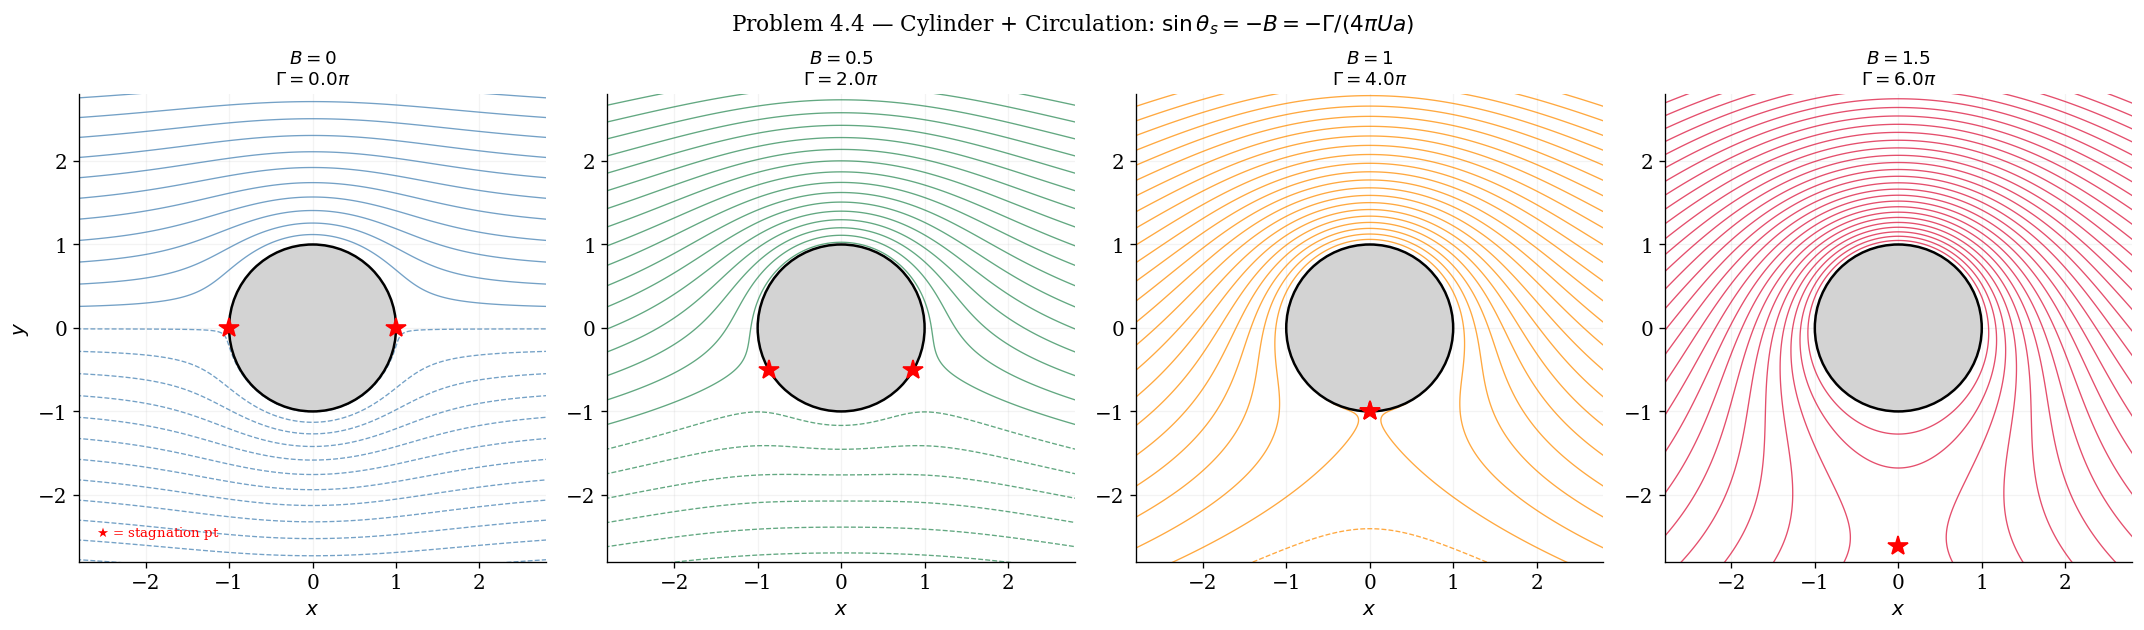

Saved: fig_4_4_cylinder_circulation.png


In [4]:
\
U, a = 1.0, 1.0

x = np.linspace(-3, 3, 600)
y = np.linspace(-3, 3, 600)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y
mask = (X**2 + Y**2) < a**2

B_vals   = [0.0, 0.5, 1.0, 1.5]
labels   = ['$B=0$', '$B=0.5$', '$B=1$', '$B=1.5$']
colors_B = ['steelblue', 'seagreen', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))

for ax, B, lbl, col in zip(axes, B_vals, labels, colors_B):
    Gamma = 4*np.pi*U*a*B   # Γ = 4πUaB

    R   = np.abs(Z)
    R   = np.where(R < 1e-6, 1e-6, R)
    Th  = np.angle(Z)
    PHI = U*(R + a**2/R)*np.cos(Th) - Gamma/(2*np.pi)*Th
    PSI = U*(R - a**2/R)*np.sin(Th) + Gamma/(2*np.pi)*np.log(R)
    PSI_plot = np.where(mask, np.nan, PSI)

    # Streamlines
    psi0 = float(np.nanmin(PSI_plot[~mask if hasattr(mask,'__len__') else True]))
    levels = np.linspace(psi0, psi0+8, 35)
    ax.contour(X, Y, PSI_plot, levels=levels, colors=col, linewidths=0.8, alpha=0.75)

    cyl = Circle((0,0), a, color='lightgray', ec='k', lw=1.5, zorder=5)
    ax.add_patch(cyl)

    # Stagnation points
    sinT = -B
    if abs(sinT) <= 1:
        for sgn in [+1, -1]:
            theta_s = np.arcsin(sinT)
            if sgn == -1:
                theta_s = np.pi - theta_s
            xs, ys = a*np.cos(theta_s), a*np.sin(theta_s)
            ax.plot(xs, ys, 'r*', ms=12, zorder=7)
    else:   # stagnation off the cylinder
        # r where u_r=0 and u_theta=0: r = Γ/(4πU·2)... numeric
        for sign_r in [+1, -1]:
            r_s = abs(Gamma)/(4*np.pi*U) + sign_r*np.sqrt((Gamma/(4*np.pi*U))**2 - a**2 + 0j)
            if np.isreal(r_s) and r_s.real > a:
                ax.plot(0, r_s.real*(-np.sign(Gamma)), 'r*', ms=12, zorder=7)

    ax.set_xlabel('$x$'); ax.set_ylabel('$y$') if ax == axes[0] else None
    ax.set_title(lbl + f'\n$\\Gamma={Gamma/(np.pi):.1f}\\pi$', fontsize=11)
    ax.set_aspect('equal'); ax.set_xlim(-2.8,2.8); ax.set_ylim(-2.8,2.8)
    ax.grid(True, alpha=0.15)

axes[0].text(-2.6, -2.5, r'$\bigstar$ = stagnation pt', fontsize=8, color='red')
plt.suptitle(r'Problem 4.4 — Cylinder + Circulation: $\sin\theta_s = -B = -\Gamma/(4\pi Ua)$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.0)
plt.savefig(FIG_DIR / 'fig_4_4_cylinder_circulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_4_cylinder_circulation.png')

---
## Problem 4.6 — Kutta Condition

Surface speed on cylinder $r=a$ (mapped to flat plate via Joukowski):
$|u_\theta| = 2U|\sin\theta + \sin\alpha|$

The Kutta circulation $\Gamma = -4\pi Ua\sin\alpha$ makes $dw/dz=0$ at the trailing edge $z=a$ ($\theta=0$).


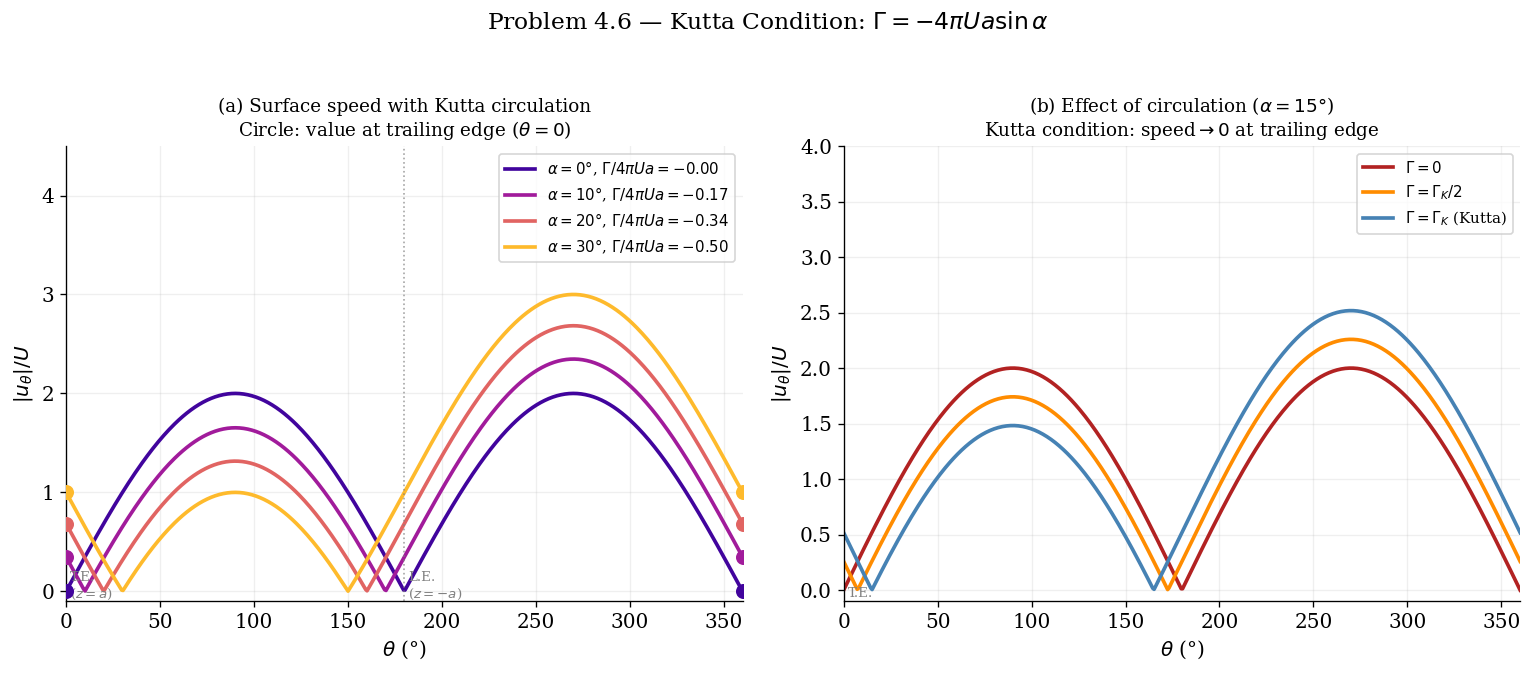

Saved: fig_4_6_kutta.png


In [5]:
\
U, a = 1.0, 1.0
theta = np.linspace(0, 2*np.pi, 500)

alpha_vals = [0, 10, 20, 30]   # degrees
colors_a   = plt.cm.plasma(np.linspace(0.1, 0.85, len(alpha_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: surface speed |u_theta| on cylinder ─────────────────────────────────
ax = axes[0]
for alpha_deg, col in zip(alpha_vals, colors_a):
    al = np.radians(alpha_deg)
    Gamma = -4*np.pi*U*a*np.sin(al)   # Kutta circulation
    u_th = np.abs(-2*U*np.sin(theta) - Gamma/(2*np.pi*a))
    ax.plot(np.degrees(theta), u_th, color=col, lw=2.2,
            label=fr'$\alpha={alpha_deg}°$, $\Gamma/4\pi Ua={-np.sin(al):.2f}$')
    # Mark trailing edge (theta=0) → speed should be 0 with Kutta
    ax.plot(0,   u_th[0],   'o', color=col, ms=8, zorder=6)
    ax.plot(360, u_th[-1],  'o', color=col, ms=8, zorder=6)

ax.axvline(0,   color='gray', lw=1.0, ls=':', alpha=0.7)
ax.axvline(180, color='gray', lw=1.0, ls=':', alpha=0.7)
ax.text( 2, -0.06, 'T.E.\n($z=a$)', fontsize=8, color='gray', ha='left')
ax.text(182, -0.06, 'L.E.\n($z=-a$)', fontsize=8, color='gray', ha='left')
ax.set_xlabel(r'$\theta$ (°)'); ax.set_ylabel(r'$|u_\theta|/U$')
ax.set_title('(a) Surface speed with Kutta circulation\n'
             r'Circle: value at trailing edge ($\theta=0$)', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(0, 360); ax.set_ylim(-0.1, 4.5)
ax.grid(True, alpha=0.2)

# ── Right: WITHOUT Kutta — speed diverges at trailing edge ────────────────────
ax = axes[1]
# Fix alpha=15°, vary Gamma to show how Kutta selects the right one
al = np.radians(15)
Gamma_kutta = -4*np.pi*U*a*np.sin(al)
for frac, col, lbl in [(0, 'firebrick', '$\\Gamma=0$'),
                       (0.5, 'darkorange', '$\\Gamma=\\Gamma_K/2$'),
                       (1.0, 'steelblue', '$\\Gamma=\\Gamma_K$ (Kutta)')]:
    Gamma_i = frac * Gamma_kutta
    u_th = np.abs(-2*U*np.sin(theta) - Gamma_i/(2*np.pi*a))
    ax.plot(np.degrees(theta), u_th, color=col, lw=2.2, label=lbl)

ax.axvline(0, color='gray', lw=1.0, ls=':', alpha=0.7)
ax.text(2, -0.06, 'T.E.', fontsize=8, color='gray')
ax.set_xlabel(r'$\theta$ (°)'); ax.set_ylabel(r'$|u_\theta|/U$')
ax.set_title(r'(b) Effect of circulation ($\alpha=15°$)''\n'
             'Kutta condition: speed$\\to0$ at trailing edge', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(0, 360); ax.set_ylim(-0.1, 4.0)
ax.grid(True, alpha=0.2)

plt.suptitle(r'Problem 4.6 — Kutta Condition: $\Gamma=-4\pi Ua\sin\alpha$',
             fontsize=14, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_4_6_kutta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_6_kutta.png')

---
## Problem 4.7 — Flat-Plate Aerofoil: Pressure Distribution

$s = X/2a = \cos\theta$. Pressure difference across plate:
$$p_D = 2\rho U^2\!\left(\dfrac{1-s}{1+s}\right)^{1/2}\!\sin\alpha\cos\alpha$$
Lift: $\mathcal{L} = \pi\rho U^2\cdot 2a\cdot\sin\alpha$. Lift acts at quarter-chord from leading edge.


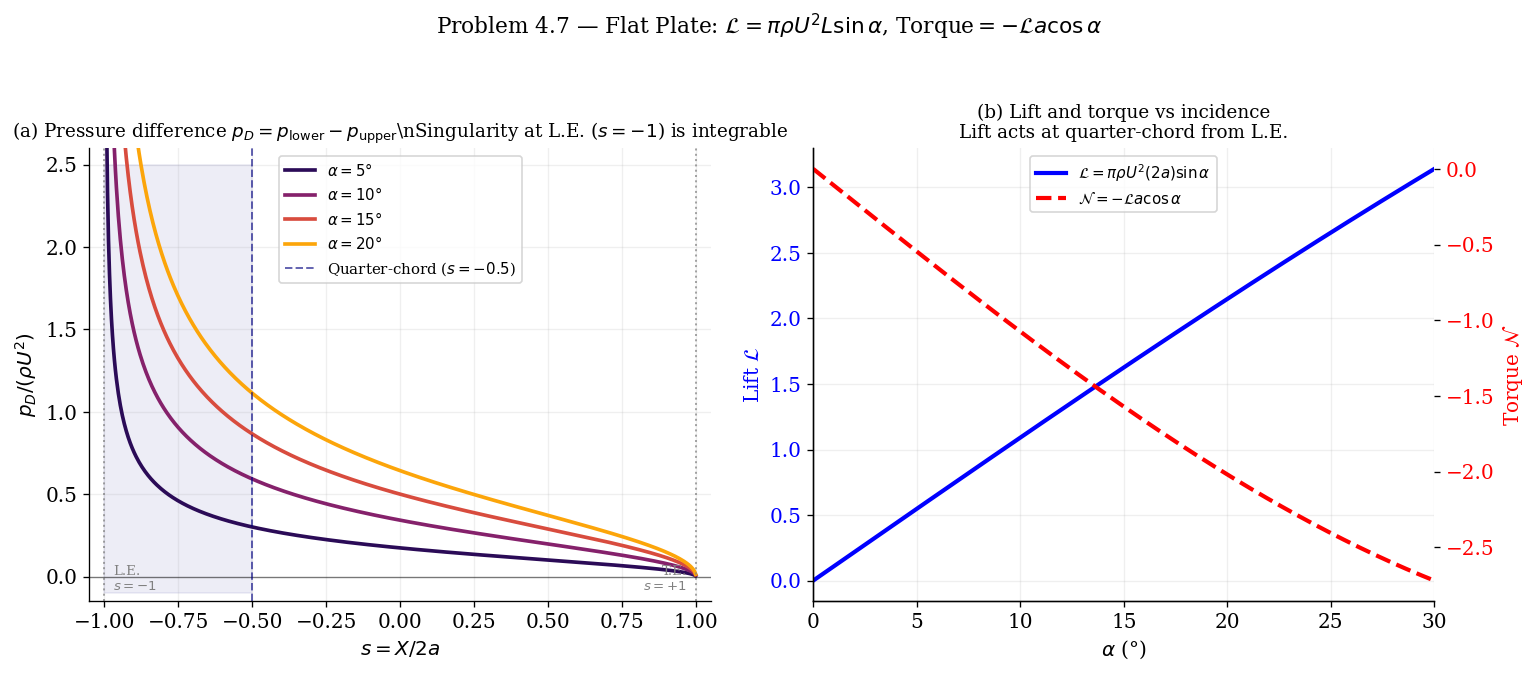

Saved: fig_4_7_flatplate.png


In [6]:
\
U, a_plate = 1.0, 1.0
rho = 1.0
s = np.linspace(-0.999, 0.999, 600)  # s = X/2a, avoid endpoints

alpha_vals2 = [5, 10, 15, 20]
colors_p    = plt.cm.inferno(np.linspace(0.15, 0.8, len(alpha_vals2)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: pressure distribution ───────────────────────────────────────────────
ax = axes[0]
for alpha_deg, col in zip(alpha_vals2, colors_p):
    al = np.radians(alpha_deg)
    ratio = np.sqrt((1-s)/(1+s))
    p_D = 2*rho*U**2 * ratio * np.sin(al)*np.cos(al)   # lower - upper
    ax.plot(s, p_D, color=col, lw=2.2, label=fr'$\alpha={alpha_deg}°$')

ax.axhline(0, color='k', lw=0.8, alpha=0.5)
ax.axvline(-1, color='gray', lw=1.2, ls=':', alpha=0.7)
ax.axvline( 1, color='gray', lw=1.2, ls=':', alpha=0.7)
ax.text(-0.97, -0.08, 'L.E.\n$s=-1$', fontsize=8, color='gray', ha='left')
ax.text( 0.97, -0.08, 'T.E.\n$s=+1$', fontsize=8, color='gray', ha='right')
# Quarter-chord marker
ax.axvline(-0.5, color='navy', lw=1.2, ls='--', alpha=0.6, label='Quarter-chord ($s=-0.5$)')
ax.fill_betweenx([-0.1, 2.5], -1, -0.5, alpha=0.07, color='navy')
ax.set_xlabel(r'$s = X/2a$'); ax.set_ylabel(r'$p_D / (\rho U^2)$')
ax.set_title(r'(a) Pressure difference $p_D = p_\mathrm{lower}-p_\mathrm{upper}$\n'
             r'Singularity at L.E. ($s=-1$) is integrable', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(-1.05, 1.05); ax.set_ylim(-0.15, 2.6)
ax.grid(True, alpha=0.2)

# ── Right: lift and torque vs alpha ───────────────────────────────────────────
ax = axes[1]
alphas = np.linspace(0, 30, 200)
al_r = np.radians(alphas)
L_vals = np.pi*rho*U**2 * 2*a_plate * np.sin(al_r)
N_vals = -L_vals * a_plate * np.cos(al_r)   # torque about origin = -L·a·cosα

ax2 = ax.twinx()
lL, = ax.plot(alphas, L_vals, 'b-', lw=2.5, label=r'$\mathcal{L}=\pi\rho U^2(2a)\sin\alpha$')
lN, = ax2.plot(alphas, N_vals, 'r--', lw=2.5, label=r'$\mathcal{N}=-\mathcal{L}a\cos\alpha$')
ax.set_xlabel(r'$\alpha$ (°)'); ax.set_ylabel(r'Lift $\mathcal{L}$', color='b')
ax2.set_ylabel(r'Torque $\mathcal{N}$', color='r')
ax.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')

# Mark quarter-chord: moment arm = a·cosα
ax.set_title('(b) Lift and torque vs incidence\n'
             r'Lift acts at quarter-chord from L.E.', fontsize=11)
lines = [lL, lN]
ax.legend(lines, [l.get_label() for l in lines], fontsize=9, loc="upper center")
ax.set_xlim(0, 30); ax.grid(True, alpha=0.2)

plt.suptitle(r'Problem 4.7 — Flat Plate: $\mathcal{L}=\pi\rho U^2 L\sin\alpha$, Torque$=-\mathcal{L}a\cos\alpha$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_4_7_flatplate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_7_flatplate.png')

---
## Problem 4.8 — Joukowski Transform: Circle → Circular Arc

Map $Z = z + a^2/z$ sends the off-centre circle (radius $a/\sin\beta$, centre $ia\cot\beta$)
to a circular arc of half-chord $2a$ subtending angle $2\beta$.


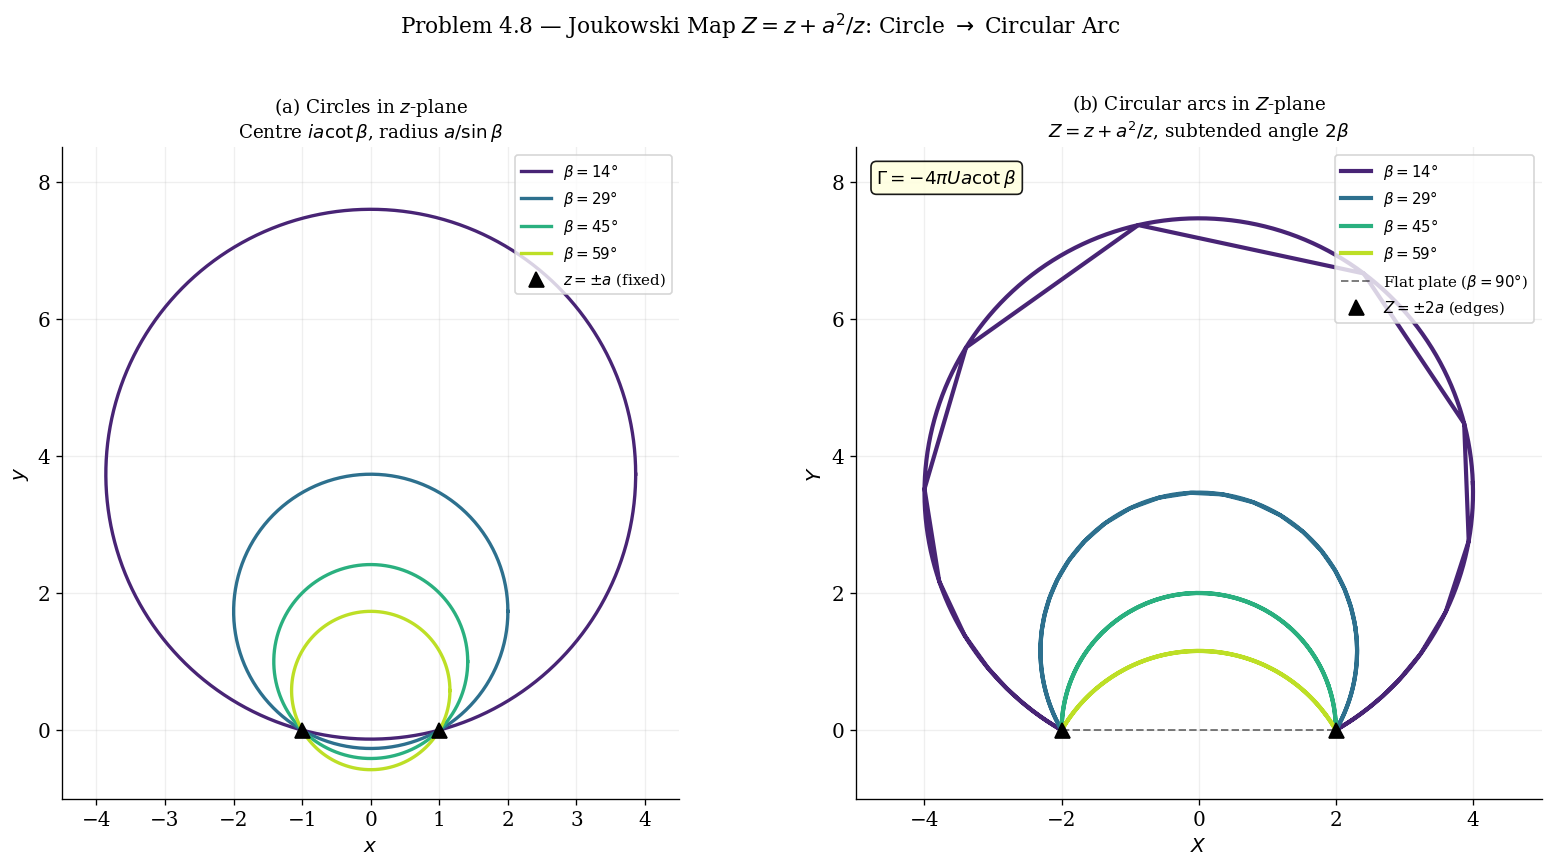

Saved: fig_4_8_joukowski.png


In [7]:
a_J = 1.0

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

beta_vals = [np.radians(b) for b in [15, 30, 45, 60]]
cmap_vals = plt.cm.viridis(np.linspace(0.1, 0.9, len(beta_vals)))

phi_circ = np.linspace(0, 2*np.pi, 400)

# ── Left: circles in z-plane ──────────────────────────────────────────────────
ax = axes[0]

for beta, col in zip(beta_vals, cmap_vals):
    R_c  = a_J / np.sin(beta)
    z0   = 1j * a_J / np.tan(beta)
    z_c  = z0 + R_c * np.exp(1j*phi_circ)
    ax.plot(z_c.real, z_c.imag, color=col, lw=2,
            label=fr'$\beta={int(np.degrees(beta))}°$')

ax.plot([ a_J, -a_J], [0, 0], 'k^', ms=9, zorder=6)
ax.plot([], [], 'k^', ms=9, label='$z=\\pm a$ (fixed)')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Circles in $z$-plane\n'
             r'Centre $ia\cot\beta$, radius $a/\sin\beta$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-1.0, 8.5)
ax.grid(True, alpha=0.2)

# ── Right: circular arcs in Z-plane ───────────────────────────────────────────
ax = axes[1]

for beta, col in zip(beta_vals, cmap_vals):
    R_c  = a_J / np.sin(beta)
    z0   = 1j * a_J / np.tan(beta)
    z_c  = z0 + R_c * np.exp(1j*phi_circ)
    Z_c  = z_c + a_J**2 / z_c
    ax.plot(Z_c.real, Z_c.imag, color=col, lw=2.5,
            label=fr'$\beta={int(np.degrees(beta))}°$')

ax.plot([-2*a_J, 2*a_J], [0, 0], 'k--', lw=1.2, alpha=0.5,
        label='Flat plate ($\\beta=90°$)')
ax.plot([ 2*a_J, -2*a_J], [0, 0], 'k^', ms=9, zorder=6)
ax.plot([], [], 'k^', ms=9, label='$Z=\\pm 2a$ (edges)')
ax.set_xlabel('$X$'); ax.set_ylabel('$Y$')
ax.set_title('(b) Circular arcs in $Z$-plane\n'
             r'$Z = z + a^2/z$, subtended angle $2\beta$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')
ax.set_xlim(-5.0, 5.0)
ax.set_ylim(-1.0, 8.5)
ax.grid(True, alpha=0.2)

ax.text(0.03, 0.97,
        r'$\Gamma=-4\pi Ua\cot\beta$',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

plt.suptitle(r'Problem 4.8 — Joukowski Map $Z=z+a^2/z$: Circle $\to$ Circular Arc',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_4_8_joukowski.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_8_joukowski.png')

---
## Problem 4.9 — Line Source Between Parallel Walls

$w(z) = \dfrac{Q}{2\pi}\log\sinh\!\dfrac{\pi z}{2b}$

Left: streamlines (images method). Right: far-field approach to uniform stream $Q/2b$.


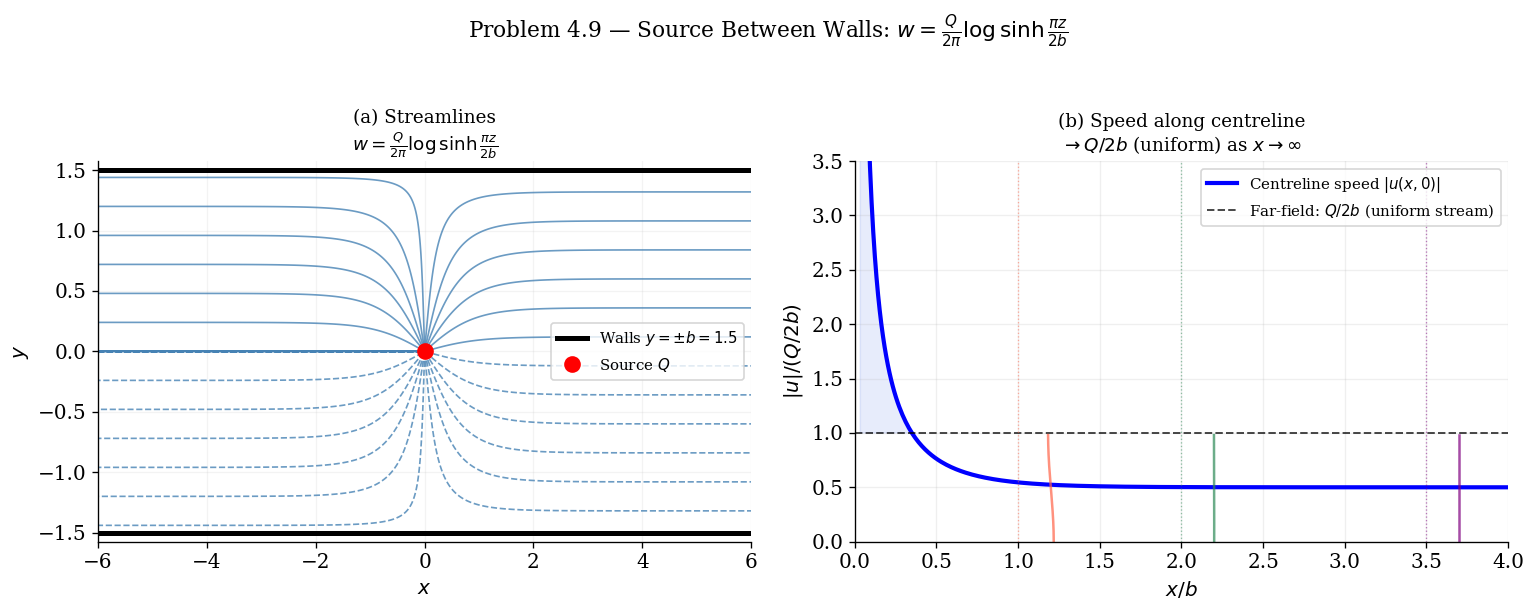

Saved: fig_4_9_source_walls.png


In [8]:
\
Q, b = 1.0, 1.5

x = np.linspace(-4*b, 4*b, 700)
y = np.linspace(-b, b, 400)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Complex potential w = Q/(2pi) * log(sinh(pi*z / 2b))
arg = np.pi*Z/(2*b)
# Careful: sinh can overflow for large Re(arg)
W = Q/(2*np.pi) * np.log(np.sinh(arg) + 1e-300j)
PSI  = np.imag(W)
dWdZ = Q/(2*np.pi) * np.cosh(arg) / (np.sinh(arg) + 1e-300j) * (np.pi/(2*b))
speed = np.abs(dWdZ)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

# ── Left: streamlines ─────────────────────────────────────────────────────────
ax = axes[0]
levels_psi = np.linspace(-Q/2, Q/2, 26)
ax.contour(X, Y, PSI, levels=levels_psi, colors='steelblue', linewidths=1.0, alpha=0.8)
ax.axhline( b, color='k', lw=3, label=f'Walls $y=\\pm b={b}$')
ax.axhline(-b, color='k', lw=3)
ax.plot(0, 0, 'ro', ms=9, zorder=6, label='Source $Q$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Streamlines\n'
             r'$w = \frac{Q}{2\pi}\log\sinh\frac{\pi z}{2b}$', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(-4*b, 4*b); ax.set_ylim(-b*1.05, b*1.05)
ax.grid(True, alpha=0.15)

# ── Right: speed profile — approach to uniform stream ─────────────────────────
ax = axes[1]
# Speed along centreline y=0 (x > 0)
x_line = np.linspace(0.05, 4*b, 400)
z_line = x_line + 0j
arg_l  = np.pi*z_line/(2*b)
dw_l   = Q/(2*np.pi) * np.cosh(arg_l)/np.sinh(arg_l) * np.pi/(2*b)
U_inf  = Q/(2*b)

ax.plot(x_line/b, np.abs(dw_l)/U_inf, 'b-', lw=2.5, label='Centreline speed $|u(x,0)|$')
ax.axhline(1, color='k', lw=1.2, ls='--', alpha=0.7,
           label=r'Far-field: $Q/2b$ (uniform stream)')
ax.fill_between(x_line/b, np.abs(dw_l)/U_inf, 1,
                where=(np.abs(dw_l)/U_inf > 1), alpha=0.12, color='royalblue')

# Speed at y=0, several x-slices shown as profiles
for x0, col in [(b, 'tomato'), (2*b, 'seagreen'), (3.5*b, 'purple')]:
    y_sl = np.linspace(-b*0.98, b*0.98, 200)
    z_sl = x0 + 1j*y_sl
    arg_sl = np.pi*z_sl/(2*b)
    dw_sl  = Q/(2*np.pi)*np.cosh(arg_sl)/np.sinh(arg_sl)*np.pi/(2*b)
    # Plot as inset horizontal profiles
    ax.plot(x0/b + np.abs(dw_sl)/U_inf * 0.4, y_sl/b,
            color=col, lw=1.5, alpha=0.7)
    ax.axvline(x0/b, color=col, lw=0.8, ls=':', alpha=0.5)

ax.set_xlabel('$x/b$'); ax.set_ylabel(r'$|u|/(Q/2b)$')
ax.set_title('(b) Speed along centreline\n'
             r'$\to Q/2b$ (uniform) as $x\to\infty$', fontsize=11)
ax.legend(fontsize=9); ax.set_xlim(0, 4); ax.set_ylim(0, 3.5)
ax.grid(True, alpha=0.2)

plt.suptitle(r'Problem 4.9 — Source Between Walls: $w=\frac{Q}{2\pi}\log\sinh\frac{\pi z}{2b}$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_4_9_source_walls.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_9_source_walls.png')

---
## Problem 4.10 — Drag on Aerofoil Pair

Two vortices at $z=\pm id$, each circulation $\Gamma$.
Far-field $|dw/dz|\sim\Gamma/\pi r$ — slower decay than a dipole.
Momentum integral gives $F_x = \rho\Gamma^2/2d$ on each aerofoil.


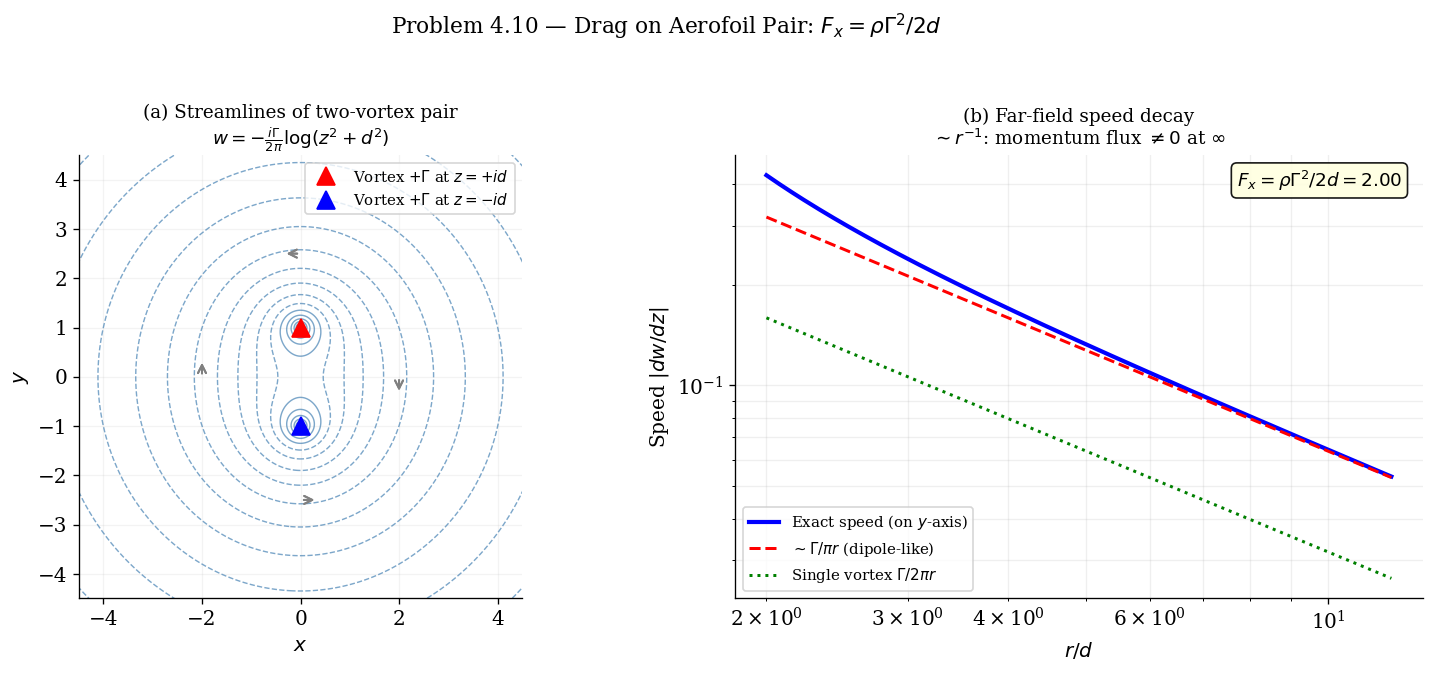

Saved: fig_4_10_pair_drag.png


In [9]:
\
d, Gamma_pair, rho_p = 1.0, 2.0, 1.0

x = np.linspace(-5, 5, 700)
y = np.linspace(-5, 5, 700)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# w = -iΓ/(2π) [log(z-id) + log(z+id)]
eps = 1e-6
W_pair = -1j*Gamma_pair/(2*np.pi) * (
    np.log(Z - 1j*d + eps) + np.log(Z + 1j*d + eps))
PSI_pair = np.imag(W_pair)

dWdZ = -1j*Gamma_pair/(2*np.pi) * (1/(Z - 1j*d) + 1/(Z + 1j*d))
speed_p = np.abs(dWdZ)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left: streamlines ─────────────────────────────────────────────────────────
ax = axes[0]
levels_p = np.linspace(-3, 3, 50)
ax.contour(X, Y, PSI_pair, levels=levels_p, colors='steelblue', linewidths=0.85, alpha=0.7)
ax.plot(0,  d, 'r^', ms=11, zorder=6, label=r'Vortex $+\Gamma$ at $z=+id$')
ax.plot(0, -d, 'b^', ms=11, zorder=6, label=r'Vortex $+\Gamma$ at $z=-id$')

# Induced velocity direction arrows
for yv, col in [(d, 'red'), (-d, 'blue')]:
    for xp, yp in [(-2, 0), (2, 0), (0, 2.5), (0, -2.5)]:
        dw_pt = -1j*Gamma_pair/(2*np.pi)*(1/((xp+1j*yp)-1j*d)+1/((xp+1j*yp)+1j*d))
        speed_pt = abs(dw_pt) + 1e-9
        dx, dy = dw_pt.real/speed_pt*0.35, dw_pt.imag/speed_pt*0.35
        ax.annotate('', xy=(xp+dx, yp+dy), xytext=(xp, yp),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('(a) Streamlines of two-vortex pair\n'
             r'$w=-\frac{i\Gamma}{2\pi}\log(z^2+d^2)$', fontsize=11)
ax.legend(fontsize=9); ax.set_aspect('equal')
ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
ax.grid(True, alpha=0.15)

# ── Right: far-field speed decay vs r ─────────────────────────────────────────
ax = axes[1]
r_arr = np.linspace(2*d, 12*d, 400)
# Exact centreline (theta=pi/2): |dw/dz| at z=r*i
speed_exact = np.abs(-1j*Gamma_pair/(2*np.pi) * (1/(r_arr*1j - 1j*d) + 1/(r_arr*1j + 1j*d)))
speed_far1  = Gamma_pair/(np.pi*r_arr)          # ~ 1/r (leading term)
speed_far2  = Gamma_pair*d**2/(np.pi*r_arr**3)  # correction

ax.loglog(r_arr/d, speed_exact, 'b-', lw=2.5, label='Exact speed (on $y$-axis)')
ax.loglog(r_arr/d, speed_far1,  'r--', lw=1.8, label=r'$\sim\Gamma/\pi r$ (dipole-like)')
ax.loglog(r_arr/d, Gamma_pair/(2*np.pi*r_arr),
          'g:', lw=1.8, label=r'Single vortex $\Gamma/2\pi r$')
ax.set_xlabel('$r/d$'); ax.set_ylabel('Speed $|dw/dz|$')
ax.set_title('(b) Far-field speed decay\n'
             r'$\sim r^{-1}$: momentum flux $\neq 0$ at $\infty$', fontsize=11)

# Annotate drag formula
F_x = rho_p * Gamma_pair**2 / (2*d)
ax.text(0.97, 0.97,
        rf'$F_x = \rho\Gamma^2/2d = {F_x:.2f}$',
        transform=ax.transAxes, fontsize=11, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax.legend(fontsize=9); ax.grid(True, alpha=0.2, which='both')

plt.suptitle(r'Problem 4.10 — Drag on Aerofoil Pair: $F_x = \rho\Gamma^2/2d$',
             fontsize=13, y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig(FIG_DIR / 'fig_4_10_pair_drag.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_4_10_pair_drag.png')

---
## Summary of saved figures

| File | Problem |
|------|---------|
| `fig_4_2_source.png` | 4.2 Line source/sink |
| `fig_4_3_cylinder_stagnation.png` | 4.3 Cylinder in stagnation-like flow |
| `fig_4_4_cylinder_circulation.png` | 4.4 Cylinder + circulation |
| `fig_4_6_kutta.png` | 4.6 Kutta condition |
| `fig_4_7_flatplate.png` | 4.7 Flat-plate pressure distribution |
| `fig_4_8_joukowski.png` | 4.8 Joukowski transform |
| `fig_4_9_source_walls.png` | 4.9 Source between walls |
| `fig_4_10_pair_drag.png` | 4.10 Aerofoil pair drag |


In [10]:
# ── Package all figures and download (Colab) ───────────────────────────────────
import zipfile
from pathlib import Path

zip_path = Path('ch04_figures.zip')
fig_files = [
    'fig_4_2_source.png',
    'fig_4_3_cylinder_stagnation.png',
    'fig_4_4_cylinder_circulation.png',
    'fig_4_6_kutta.png',
    'fig_4_7_flatplate.png',
    'fig_4_8_joukowski.png',
    'fig_4_9_source_walls.png',
    'fig_4_10_pair_drag.png',
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in fig_files:
        fpath = FIG_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            print(f'  added: {fname}  ({fpath.stat().st_size/1024:.0f} KB)')
        else:
            print(f'  MISSING: {fname} — run the cell above first')

total_kb = zip_path.stat().st_size / 1024
print(f'\nZip: {zip_path}  ({total_kb:.0f} KB)')

try:
    from google.colab import files
    files.download(str(zip_path))
    print('Download started.')
except ImportError:
    print(f'Not in Colab — file saved locally at: {zip_path.resolve()}')

  added: fig_4_2_source.png  (233 KB)
  added: fig_4_3_cylinder_stagnation.png  (706 KB)
  added: fig_4_4_cylinder_circulation.png  (644 KB)
  added: fig_4_6_kutta.png  (226 KB)
  added: fig_4_7_flatplate.png  (175 KB)
  added: fig_4_8_joukowski.png  (188 KB)
  added: fig_4_9_source_walls.png  (174 KB)
  added: fig_4_10_pair_drag.png  (211 KB)

Zip: ch04_figures.zip  (2474 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
